In [89]:
# Cell 1 - Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('reports', exist_ok=True)

# Load data
nav_df = pd.read_csv('data/processed/nav_history_clean.csv')
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

bench_df = pd.read_csv('data/raw/10_benchmark_indices.csv')
bench_df['date'] = pd.to_datetime(bench_df.iloc[:, 0])

perf_df = pd.read_csv('data/processed/scheme_performance_clean.csv')

print("✅ Data loaded!")
print("NAV shape:", nav_df.shape)
print("Benchmark columns:", bench_df.columns.tolist())
print("Performance columns:", perf_df.columns.tolist())

✅ Data loaded!
NAV shape: (46000, 3)
Benchmark columns: ['date', 'index_name', 'close_value']
Performance columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'is_anomaly']


Daily Returns Summary:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


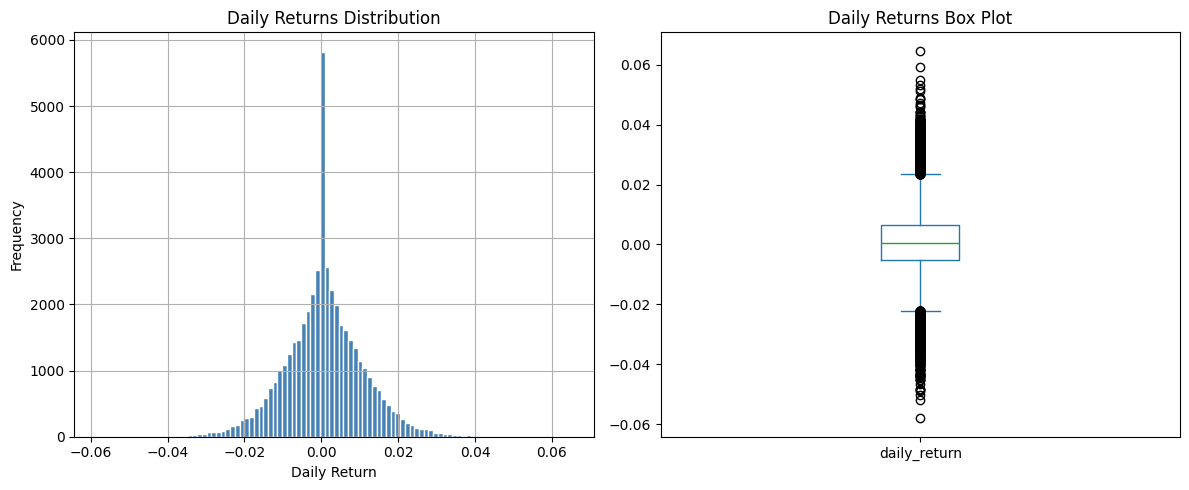

✅ Daily returns computed!


In [90]:
# Cell 2 - Compute Daily Returns
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Validate distribution
print("Daily Returns Summary:")
print(nav_df['daily_return'].describe())

# Plot distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
nav_df['daily_return'].hist(bins=100, color='steelblue', edgecolor='white')
plt.title('Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
nav_df['daily_return'].dropna().plot(kind='box')
plt.title('Daily Returns Box Plot')

plt.tight_layout()
plt.savefig('reports/daily_returns.png', dpi=150)
plt.show()
print("✅ Daily returns computed!")

In [91]:
# Cell 3 - CAGR for 1yr, 3yr, 5yr
def compute_cagr(group, years):
    group = group.sort_values('date')
    days = years * 252
    if len(group) < days:
        return np.nan
    nav_start = group.iloc[-days]['nav']
    nav_end = group.iloc[-1]['nav']
    return (nav_end / nav_start) ** (1/years) - 1

cagr_results = []
for code, group in nav_df.groupby('amfi_code'):
    cagr_results.append({
        'amfi_code': code,
        'cagr_1yr': compute_cagr(group, 1),
        'cagr_3yr': compute_cagr(group, 3),
        'cagr_5yr': compute_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)
print("✅ CAGR computed!")
print(cagr_df.head())

✅ CAGR computed!
   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.033055 -0.000316       NaN
1     100025  0.025018  0.046143       NaN
2     100033  0.477346  0.336292       NaN
3     101206  0.450939  0.325286       NaN
4     101207 -0.242421 -0.026965       NaN


In [92]:
# Cell 4 - Sharpe Ratio
Rf = 0.065 / 252  # RBI repo rate daily

sharpe_results = []
for code, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    excess = returns - Rf
    if returns.std() == 0:
        sharpe = np.nan
    else:
        sharpe = (excess.mean() / returns.std()) * np.sqrt(252)
    sharpe_results.append({
        'amfi_code': code,
        'sharpe_ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)
print("✅ Sharpe Ratio computed!")
print(sharpe_df.sort_values('sharpe_ratio', ascending=False).head(10))

✅ Sharpe Ratio computed!
    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101
38     149323      1.132122
2      100033      1.093699
9      118632      1.081659
3      101206      1.027213
24     120504      1.026524


In [93]:
# Cell 5 - Sortino Ratio
sortino_results = []
for code, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    excess = returns - Rf
    downside = returns[returns < 0].std()
    if downside == 0:
        sortino = np.nan
    else:
        sortino = (excess.mean() / downside) * np.sqrt(252)
    sortino_results.append({
        'amfi_code': code,
        'sortino_ratio': sortino
    })

sortino_df = pd.DataFrame(sortino_results)
print("✅ Sortino Ratio computed!")
print(sortino_df.sort_values('sortino_ratio', ascending=False).head(10))

✅ Sortino Ratio computed!
    amfi_code  sortino_ratio
34     148567       2.385644
30     120843       2.364320
36     148569       2.146914
19     119551       2.140267
25     120505       2.029353
38     149323       1.875101
9      118632       1.850133
2      100033       1.829134
24     120504       1.805294
3      101206       1.799563


In [94]:
# Cell 6 - Alpha and Beta FIXED
# First check benchmark columns
print("Benchmark columns:", bench_df.columns.tolist())
print(bench_df.head(3))

# Get numeric columns only
bench_df2 = bench_df.copy()
bench_df2['date'] = pd.to_datetime(bench_df2.iloc[:, 0], errors='coerce')

# Find numeric column for benchmark
num_cols = bench_df2.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)

if len(num_cols) > 0:
    bench_col = num_cols[0]
    bench_df2['bench_return'] = bench_df2[bench_col].pct_change()
else:
    bench_df2['bench_return'] = bench_df2.iloc[:, 1].apply(
        pd.to_numeric, errors='coerce').pct_change()

alpha_beta_results = []
for code, group in nav_df.groupby('amfi_code'):
    merged = pd.merge(
        group[['date', 'daily_return']].dropna(),
        bench_df2[['date', 'bench_return']].dropna(),
        on='date'
    )
    if len(merged) < 30:
        continue
    try:
        slope, intercept, r, p, se = stats.linregress(
            merged['bench_return'].values,
            merged['daily_return'].values
        )
        alpha_beta_results.append({
            'amfi_code': code,
            'alpha': intercept * 252,
            'beta': slope
        })
    except Exception as e:
        print(f"Error for {code}: {e}")
        continue

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.to_csv('alpha_beta.csv', index=False)
print("✅ Alpha & Beta computed!")
print(alpha_beta_df.head(10))

Benchmark columns: ['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
Numeric columns: ['close_value']
✅ Alpha & Beta computed!
   amfi_code     alpha      beta
0     100016  0.035008  0.004843
1     100025  0.043330 -0.003422
2     100033  0.268752  0.024097
3     101206  0.214656 -0.000067
4     101207  0.110250 -0.023588
5     101208  0.060852  0.000126
6     102885  0.170941 -0.007555
7     102886  0.031949 -0.030680
8     102887  0.161063  0.011217
9     118632  0.215785  0.016157


In [95]:
# Cell 7 - Maximum Drawdown
drawdown_results = []
for code, group in nav_df.groupby('amfi_code'):
    group = group.sort_values('date')
    rolling_max = group['nav'].cummax()
    drawdown = (group['nav'] - rolling_max) / rolling_max
    max_dd = drawdown.min()
    worst_date = group.loc[drawdown.idxmin(), 'date'] if not drawdown.empty else np.nan
    drawdown_results.append({
        'amfi_code': code,
        'max_drawdown': max_dd,
        'worst_date': worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results)
print("✅ Max Drawdown computed!")
print(drawdown_df.sort_values('max_drawdown').head(10))

✅ Max Drawdown computed!
    amfi_code  max_drawdown worst_date
22     119599     -0.525742 2025-10-28
17     119095     -0.516778 2026-05-11
4      101207     -0.354469 2026-05-11
39     149324     -0.311719 2025-01-03
21     119598     -0.287060 2025-05-14
7      102886     -0.280011 2026-04-27
0      100016     -0.247344 2022-09-15
29     120842     -0.240035 2024-10-17
11     118634     -0.233449 2026-02-20
15     119093     -0.217514 2023-05-22


In [96]:
# Cell 8 - Fund Scorecard (0-100)
scorecard = cagr_df[['amfi_code', 'cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df, on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code')
scorecard = scorecard.merge(drawdown_df[['amfi_code', 'max_drawdown']], on='amfi_code')

if 'expense_ratio_pct' in perf_df.columns:
    scorecard = scorecard.merge(
        perf_df[['amfi_code', 'expense_ratio_pct']], 
        on='amfi_code', how='left'
    )

# Rank each metric
scorecard['cagr_rank'] = scorecard['cagr_3yr'].rank(pct=True) * 100
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(pct=True) * 100
scorecard['alpha_rank'] = scorecard['alpha'].rank(pct=True) * 100
scorecard['dd_rank'] = scorecard['max_drawdown'].rank(pct=True, ascending=False) * 100

# Composite score
scorecard['score'] = (
    0.30 * scorecard['cagr_rank'] +
    0.25 * scorecard['sharpe_rank'] +
    0.20 * scorecard['alpha_rank'] +
    0.25 * scorecard['dd_rank']
)

scorecard = scorecard.sort_values('score', ascending=False)
scorecard.to_csv('fund_scorecard.csv', index=False)
print("✅ Fund Scorecard created!")
print(scorecard[['amfi_code', 'score']].head(10))

✅ Fund Scorecard created!
    amfi_code   score
21     119598  84.875
25     120505  84.125
39     149324  82.625
16     119094  82.250
2      100033  80.000
36     148569  76.375
34     148567  75.250
19     119551  74.000
38     149323  73.875
30     120843  73.750


Bench columns: ['date', 'index_name', 'close_value']
date           datetime64[ns]
index_name             object
close_value           float64
dtype: object
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
After clean: (0, 3)
Empty DataFrame
Columns: [date, index_name, close_value]
Index: []


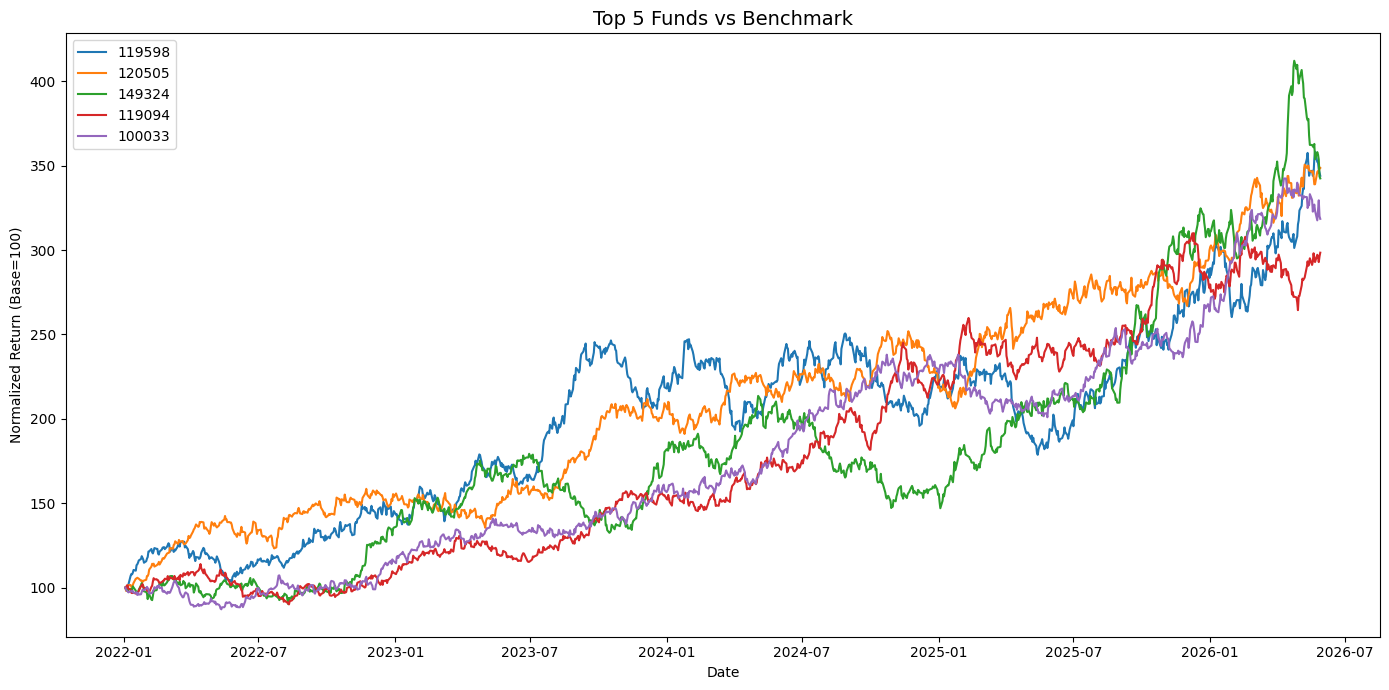

✅ Chart saved!


In [97]:
# Cell 9 - Benchmark Chart FIXED FINAL
top5 = scorecard.head(5)['amfi_code'].tolist()

plt.figure(figsize=(14, 7))

# Plot top 5 funds
for code in top5:
    fund_data = nav_df[nav_df['amfi_code'] == code].copy()
    fund_data = fund_data.sort_values('date')
    start_nav = fund_data['nav'].iloc[0]
    fund_data['normalized'] = (fund_data['nav'] / start_nav) * 100
    plt.plot(fund_data['date'],
             fund_data['normalized'],
             linewidth=1.5, label=str(code))

# Check benchmark data
print("Bench columns:", bench_df.columns.tolist())
print(bench_df.dtypes)
print(bench_df.head(3))

# Convert all columns to numeric except date
bench2 = bench_df.copy()
for col in bench2.columns:
    if col != 'date':
        bench2[col] = pd.to_numeric(
            bench2[col].astype(str).str.replace(',',''), 
            errors='coerce'
        )

bench2['date'] = pd.to_datetime(bench2.iloc[:, 0], errors='coerce')
bench2 = bench2.dropna()
bench2 = bench2.sort_values('date')

print("After clean:", bench2.shape)
print(bench2.head(3))

if len(bench2) > 0:
    num_cols = bench2.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) > 0:
        col = num_cols[0]
        start = bench2[col].iloc[0]
        bench2['normalized'] = (bench2[col] / start) * 100
        plt.plot(bench2['date'],
                 bench2['normalized'],
                 linewidth=2.5,
                 color='black',
                 linestyle='--',
                 label='Benchmark')

plt.title('Top 5 Funds vs Benchmark', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Return (Base=100)')
plt.legend()
plt.tight_layout()
plt.savefig('reports/benchmark_comparison.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [98]:
# Cell 10 - Save all results
print("=" * 50)
print("✅ PERFORMANCE ANALYTICS COMPLETE!")
print("=" * 50)
print(f"Total funds analyzed: {len(cagr_df)}")
print(f"\nTop 5 Funds by Score:")
print(scorecard[['amfi_code', 'score', 
                  'cagr_3yr', 'sharpe_ratio']].head())
print("\nFiles saved:")
print("- fund_scorecard.csv")
print("- alpha_beta.csv")
print("- reports/benchmark_comparison.png")
print("- reports/daily_returns.png")

✅ PERFORMANCE ANALYTICS COMPLETE!
Total funds analyzed: 40

Top 5 Funds by Score:
    amfi_code   score  cagr_3yr  sharpe_ratio
21     119598  84.875  0.278144      0.945308
25     120505  84.125  0.302065      1.180101
39     149324  82.625  0.250297      0.949796
16     119094  82.250  0.360660      0.998231
2      100033  80.000  0.336292      1.093699

Files saved:
- fund_scorecard.csv
- alpha_beta.csv
- reports/benchmark_comparison.png
- reports/daily_returns.png
